# 05. ResNet50V2 (Functional API, two-phase transfer)

**API.** Functional. **Backbone.** ResNet50V2, ImageNet pretrained, 224x224 input. **Training regime.** two phases (frozen backbone -> top-30% fine-tune with BatchNorm permanently frozen). **Regularization.** label smoothing 0.1, dropout in head, AdamW weight decay, cosine LR decay in phase 2.

This is the second transfer-learning model. The pair with EfficientNetV2-S (notebook 03) is deliberate: ResNet50V2 has a fundamentally different inductive bias (plain residual blocks, no compound scaling, no Fused-MBConv) and is the backbone most frequently cited in published WikiArt artist-classification work (Cetinic et al. 2018, Sandoval et al. 2019, Zhao et al. 2021). If both backbones converge to a similar test-set ceiling, the limit is dataset-driven (label noise, intra-artist variability, stylistic overlap between artists in the same movement) rather than architectural. That is the central empirical claim of the report's critical-analysis section.


### What this notebook does, step by step

**The plain-English version.** Same recipe as notebook 03 (EfficientNetV2-S) but with a ResNet50V2 backbone. Pretrained on ImageNet, we swap the classifier head, train in two phases, evaluate, and save predictions. The point is not to win — it's to pair two very different backbones under identical training and see whether they converge to a similar test-set ceiling. If they do, the bottleneck is the dataset, not the architecture.

**The technical framing.** ResNet50V2 is the backbone most frequently cited in published WikiArt artist-classification work (Cetinic et al. 2018, Sandoval et al. 2019, Zhao et al. 2021). EfficientNetV2-S has a fundamentally different inductive bias: compound scaling, Fused-MBConv blocks, swish activations. If both converge to a similar ceiling on our split, that is direct evidence for the "dataset-driven ceiling" argument we make in the report.

**Flow of the notebook.**

1. Load the 70/15/15 split at 224x224.
2. Build the `tf.data` pipeline with one-hot labels + per-sample class weights (no MixUp this time, to keep the comparison with EfficientNet cleanly attributable).
3. Define a matching conservative augmentation stack.
4. Wire the ResNet50V2 backbone + new head inside a Functional model.
5. Phase 1 training (head only, frozen backbone).
6. Phase 2 training (unfreeze top 30%, cosine LR, AdamW, BN still frozen).
7. Evaluate on the test split.
8. Persist predictions for the ensemble notebook.


In [1]:
import os, json, sys
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
import keras
from keras import layers, callbacks, optimizers, losses

# Project utils.
sys.path.append(os.path.abspath(".."))
from utils.plotting import plot_history
from utils.evaluation import evaluate_model

SPLIT_DIR  = os.path.join("..", "dataset_split")
SAVED_DIR  = os.path.join("..", "saved_models")
OUTPUT_DIR = os.path.join("..", "outputs", "resnet50v2")
CKPT_PATH  = os.path.join(SAVED_DIR, "05_functional_resnet50v2_best.keras")
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(SAVED_DIR,  exist_ok=True)

IMG_SIZE      = (224, 224)
BATCH_SIZE    = 32
SEED          = 42
PHASE1_EPOCHS = 5
PHASE2_EPOCHS = 15

keras.utils.set_random_seed(SEED)

with open(os.path.join(SPLIT_DIR, "class_weights.json")) as f:
    class_weight_dict = {int(k): float(v) for k, v in json.load(f).items()}

print(f"Keras {keras.__version__}")


Keras 3.13.2


## 1. Load data

Same on-disk split, same loader API as every other training notebook in the project. The three datasets share an identical layout so results are directly comparable across notebooks. `shuffle=False` on val and test is critical: the ensemble notebook aligns predictions by index, which only works if every notebook iterates the test set in the same order.

In [2]:
# Load the 70/15/15 split at 224x224 (the resolution ResNet50V2 was pretrained on).

train_ds = keras.utils.image_dataset_from_directory(
    os.path.join(SPLIT_DIR, "train"),
    image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode="int", shuffle=True, seed=SEED,
)
val_ds = keras.utils.image_dataset_from_directory(
    os.path.join(SPLIT_DIR, "val"),
    image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode="int", shuffle=False,
)
test_ds = keras.utils.image_dataset_from_directory(
    os.path.join(SPLIT_DIR, "test"),
    image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode="int", shuffle=False,
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
print(f"Classes ({NUM_CLASSES}): {class_names}")


Found 9338 files belonging to 23 classes.
Found 2001 files belonging to 23 classes.
Found 2001 files belonging to 23 classes.
Classes (23): ['Albrecht_Durer', 'Boris_Kustodiev', 'Camille_Pissarro', 'Childe_Hassam', 'Claude_Monet', 'Edgar_Degas', 'Eugene_Boudin', 'Gustave_Dore', 'Ilya_Repin', 'Ivan_Aivazovsky', 'Ivan_Shishkin', 'John_Singer_Sargent', 'Marc_Chagall', 'Martiros_Saryan', 'Nicholas_Roerich', 'Pablo_Picasso', 'Paul_Cezanne', 'Pierre_Auguste_Renoir', 'Pyotr_Konchalovsky', 'Raphael_Kirchner', 'Rembrandt', 'Salvador_Dali', 'Vincent_van_Gogh']


## 2. Pipeline (one-hot + class-balanced sample weights)

Labels are one-hotted so we can use `CategoricalCrossentropy(label_smoothing=0.1)`. Class imbalance is handled with a per-sample weight gathered from the inverse-frequency class weights computed in notebook 01. Doing it inside the `tf.data` pipeline (rather than via `class_weight=` in `fit`) keeps the input pipeline graph-native and matches the EfficientNet notebook's strategy for an apples-to-apples comparison.


In [3]:
# One-hot the integer labels (so we can use CategoricalCrossentropy + label smoothing) and
# attach a per-sample weight equal to the inverse-frequency class weight of each example.

class_weights_tensor = tf.constant(
    [class_weight_dict[i] for i in range(NUM_CLASSES)], dtype=tf.float32
)

def to_onehot(images, labels):
    return images, tf.one_hot(labels, NUM_CLASSES)

def add_sample_weight(images, labels):
    sw = tf.gather(class_weights_tensor, tf.argmax(labels, axis=-1))
    return images, labels, sw

AUTOTUNE = tf.data.AUTOTUNE

train_ds_w = (
    train_ds
    .map(to_onehot,         num_parallel_calls=AUTOTUNE)
    .map(add_sample_weight, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)
val_ds_oh  = val_ds.map(to_onehot,  num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
test_ds_oh = test_ds.map(to_onehot, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)


## 3. Augmentation (in-graph, conservative)

The augmentation stack is the same mild mix we used in notebook 03 (flip + small rotation / zoom / translation / contrast / brightness). Deliberately conservative: aggressive photometric jitter destroys the brushstroke and palette cues the model relies on for artist attribution (confirmed by the RandAugment ablation in notebook 02).

In [4]:
# Mild augmentation stack. Lives inside the model graph below, so it travels with the .keras
# file and is automatically disabled at inference.

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom((-0.1, 0.1)),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomContrast(0.1),
    layers.RandomBrightness(0.1),
], name="data_augmentation")


## 4. Model

Augmentation and the ResNet-V2 specific `preprocess_input` live inside the model graph so they travel with the saved `.keras` file. Head: `GAP -> Dropout(0.4) -> Dense(256, ReLU) -> Dropout(0.3) -> softmax(23)`.


In [5]:
# Functional-API model:
# inputs -> augmentation -> resnet_v2.preprocess_input -> ResNet50V2 backbone ->
# GAP -> Dropout(0.4) -> Dense(256, ReLU) -> Dropout(0.3) -> Dense(23, softmax).
# Backbone.trainable = False for phase 1 so its ImageNet weights are not corrupted.

backbone = keras.applications.ResNet50V2(
    include_top=False, weights="imagenet",
    input_shape=(*IMG_SIZE, 3), pooling=None,
)
backbone.trainable = False

inputs  = keras.Input(shape=(*IMG_SIZE, 3))
x       = data_augmentation(inputs)
x       = keras.applications.resnet_v2.preprocess_input(x)
x       = backbone(x)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dropout(0.4)(x)
x       = layers.Dense(256, activation="relu")(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = keras.Model(inputs, outputs, name="resnet50v2_artist_classifier")
model.summary()


94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "resnet50v2_artist_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 23)             │         5,911 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,095,255 (91.92 MB)

 Trainable params: 530,455 (2.02 MB)

 Non-trainable params: 23,564,800 (89.89 MB)

## 5. Phase 1: train head with frozen backbone

Only the new head trains in this phase. We use Adam with a relatively high LR (1e-3) because the head is initialised from scratch. Label smoothing 0.1 softens the one-hot targets (helps under imbalance). Early stopping on `val_accuracy` kicks in once the head saturates the capacity available to it with the backbone still frozen.

Epoch 1/5
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2391 - loss: 2.8403
Epoch 1: val_accuracy improved from None to 0.52524, saving model to ..\outputs\resnet50v2\phase1_best.keras

Epoch 1: finished saving model to ..\outputs\resnet50v2\phase1_best.keras
292/292 ━━━━━━━━━━━━━━━━━━━━ 491s 2s/step - accuracy: 0.3369 - loss: 2.4839 - val_accuracy: 0.5252 - val_loss: 1.9685
Epoch 2/5
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4571 - loss: 2.0858
Epoch 2: val_accuracy improved from 0.52524 to 0.56022, saving model to ..\outputs\resnet50v2\phase1_best.keras

Epoch 2: finished saving model to ..\outputs\resnet50v2\phase1_best.keras
292/292 ━━━━━━━━━━━━━━━━━━━━ 523s 2s/step - accuracy: 0.4648 - loss: 2.0652 - val_accuracy: 0.5602 - val_loss: 1.8647
Epoch 3/5
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5003 - loss: 1.9794
Epoch 3: val_accuracy improved from 0.56022 to 0.57221, saving model to ..\outputs\resnet50v2\phase1_best.keras

Epoch 3: finished saving mod

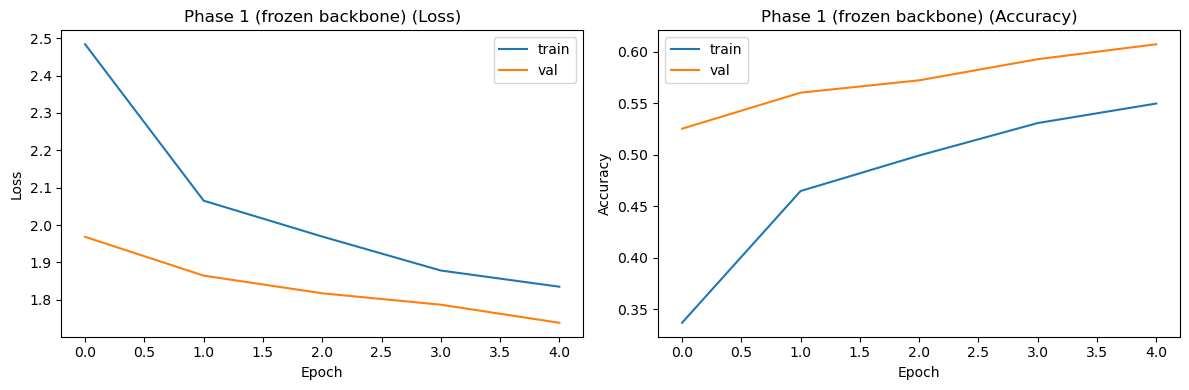

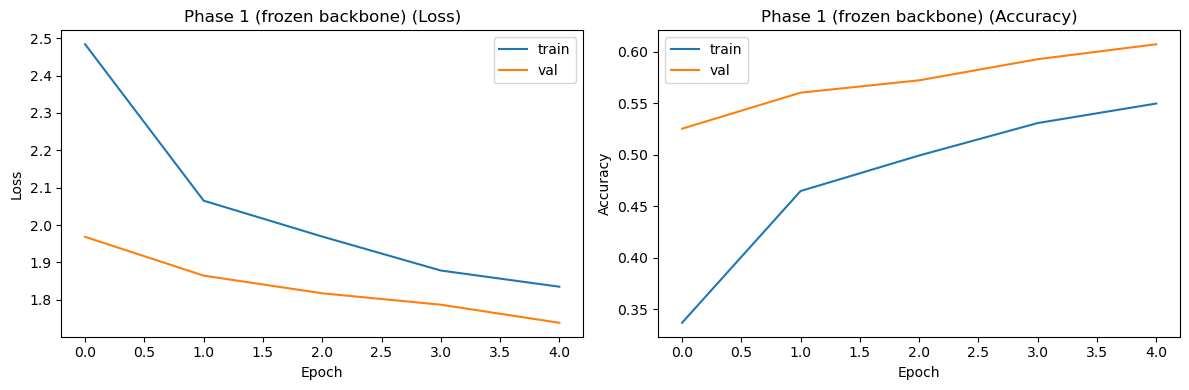

In [6]:
# Phase 1: compile + fit with only the head trainable.

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss=losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"],
)

cb_p1 = [
    callbacks.ModelCheckpoint(
        os.path.join(OUTPUT_DIR, "phase1_best.keras"),
        monitor="val_accuracy", save_best_only=True, verbose=1,
    ),
    callbacks.CSVLogger(os.path.join(OUTPUT_DIR, "phase1_log.csv")),
    callbacks.EarlyStopping(
        monitor="val_accuracy", patience=5, restore_best_weights=True, verbose=1,
    ),
]

history1 = model.fit(
    train_ds_w, validation_data=val_ds_oh,
    epochs=PHASE1_EPOCHS, callbacks=cb_p1,
)
plot_history(history1, "Phase 1 (frozen backbone)")


## 6. Phase 2: unfreeze top 30%, fine-tune

Same discipline as the EfficientNet notebook: unfreeze only the top 30% of backbone layers, drop the learning rate to 1e-4 with a cosine schedule, switch to AdamW with weight decay 1e-4, and keep every BatchNormalization layer frozen even inside the unfrozen blocks. The matching recipe is intentional: differences in test-set performance between this notebook and notebook 03 should reflect backbone capacity / inductive bias, not training-loop incidentals.


In [ ]:
# Phase 2: unfreeze the top 30% of backbone layers, keep all BatchNorm frozen, switch to AdamW
# with a cosine-decayed LR starting at 1e-4. Identical recipe to notebook 03 so differences
# between the two notebooks can be attributed to the backbone, not the training loop.

backbone.trainable = True
total_layers = len(backbone.layers)
freeze_until = int(total_layers * 0.7)

for i, layer in enumerate(backbone.layers):
    if i < freeze_until:
        layer.trainable = False
    elif isinstance(layer, layers.BatchNormalization):
        layer.trainable = False  # BN always frozen during transfer

trainable = sum(1 for l in backbone.layers if l.trainable)
frozen_bn = sum(1 for l in backbone.layers
                if isinstance(l, layers.BatchNormalization) and not l.trainable)
print(f"Backbone: {total_layers} layers, trainable={trainable}, frozen BN={frozen_bn}")

steps_per_epoch = len(train_ds_w)
cosine_schedule = optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-4,
    decay_steps=PHASE2_EPOCHS * steps_per_epoch,
    alpha=1e-6,
)

model.compile(
    optimizer=optimizers.AdamW(learning_rate=cosine_schedule, weight_decay=1e-4),
    loss=losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"],
)

cb_p2 = [
    callbacks.ModelCheckpoint(
        CKPT_PATH,
        monitor="val_accuracy", save_best_only=True, verbose=1,
    ),
    callbacks.CSVLogger(os.path.join(OUTPUT_DIR, "phase2_log.csv")),
    callbacks.EarlyStopping(
        monitor="val_accuracy", patience=8, restore_best_weights=True, verbose=1,
    ),
]

history2 = model.fit(
    train_ds_w, validation_data=val_ds_oh,
    epochs=PHASE2_EPOCHS, callbacks=cb_p2,
)
plot_history(history2, "Phase 2 (fine-tuning)")


Backbone: 190 layers, trainable=42, frozen BN=49
Epoch 1/15
 65/292 ━━━━━━━━━━━━━━━━━━━━ 7:46 2s/step - accuracy: 0.4989 - loss: 1.9979

## 7. Evaluation on held-out test set

Reload the best checkpoint (lowest validation loss across both phases) and score it on the 15% test split. Metrics reported: Top-1 / Top-3 / Top-5 accuracy, macro-F1 and weighted-F1, per-class report, confusion matrix, top-10 class confusions.

In [ ]:
# Reload the best checkpoint from disk and run the full evaluation on the held-out test set.

best_model = keras.models.load_model(CKPT_PATH)
res_results = evaluate_model(best_model, test_ds, class_names)


## 8. Persist predictions for the comparison notebook

Write `test_probs.npz` and `results.json` under `outputs/resnet50v2/`. Row ordering across notebooks is guaranteed by `shuffle=False` on the test loader — the ensemble notebook asserts this at load time.

In [ ]:
# Dump test-set probabilities + metrics for the ensemble notebook.

from sklearn.metrics import f1_score

y_true       = res_results["y_true"]
y_pred       = res_results["y_pred"]
y_pred_probs = res_results["y_pred_probs"]

results = {
    "model":       "ResNet50V2 (Functional, transfer)",
    "api":         "functional",
    "img_size":    list(IMG_SIZE),
    "n_params":    int(best_model.count_params()),
    "top1":        res_results["top_k"][1],
    "top3":        res_results["top_k"][3],
    "top5":        res_results["top_k"][5],
    "macro_f1":    res_results["macro_f1"],
    "weighted_f1": res_results["weighted_f1"],
}
with open(os.path.join(OUTPUT_DIR, "results.json"), "w") as f:
    json.dump(results, f, indent=2)
np.savez(os.path.join(OUTPUT_DIR, "test_probs.npz"),
         probs=y_pred_probs, y_true=y_true)

print(json.dumps(results, indent=2))
